In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("✅ OpenCV Image Studio Ready!")
print("OpenCV Version:", cv2.__version__)

✅ OpenCV Image Studio Ready!
OpenCV Version: 5.0.0


In [2]:
image = cv2.imread("ganesh ji.webp")

if image is None:
    print("❌ Image not found!")
else:
    print("✅ Image loaded successfully!")
    print("Image Shape:", image.shape)
    print("Height:", image.shape[0])
    print("Width:", image.shape[1])
    print("Channels:", image.shape[2])

✅ Image loaded successfully!
Image Shape: (1738, 1080, 3)
Height: 1738
Width: 1080
Channels: 3


In [4]:
def show_image(title, image, gray=False):
    
    plt.figure(figsize=(7, 5))
    
    if gray:
        plt.imshow(image, cmap="gray")
    else:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    
    plt.title(title)
    plt.axis("off")
    plt.show()

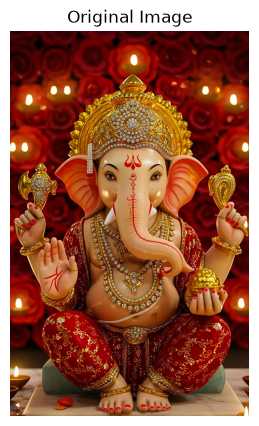

In [5]:
show_image("Original Image", image)

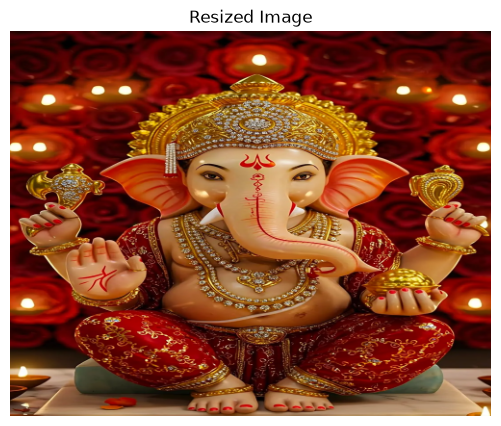

In [6]:
resized = cv2.resize(
    image,
    (500, 400),
    interpolation=cv2.INTER_AREA
)

show_image("Resized Image", resized)

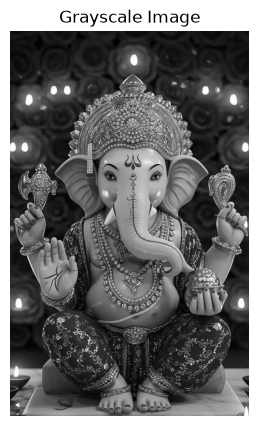

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

show_image("Grayscale Image", gray, gray=True)

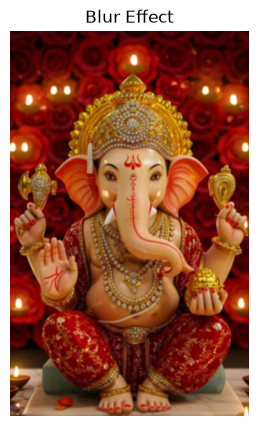

In [8]:
blurred = cv2.GaussianBlur(image, (15, 15), 0)

show_image("Blur Effect", blurred)

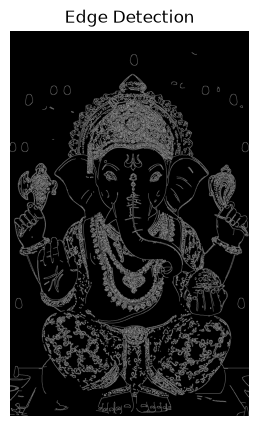

In [9]:
edges = cv2.Canny(gray, 100, 200)

show_image("Edge Detection", edges, gray=True)

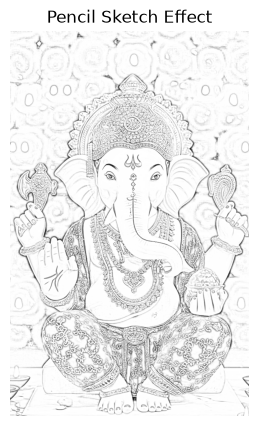

In [10]:
gray_sketch = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

inverted = cv2.bitwise_not(gray_sketch)

blurred_sketch = cv2.GaussianBlur(
    inverted,
    (21, 21),
    0
)

inverted_blur = cv2.bitwise_not(blurred_sketch)

sketch = cv2.divide(
    gray_sketch,
    inverted_blur,
    scale=256.0
)

show_image("Pencil Sketch Effect", sketch, gray=True)

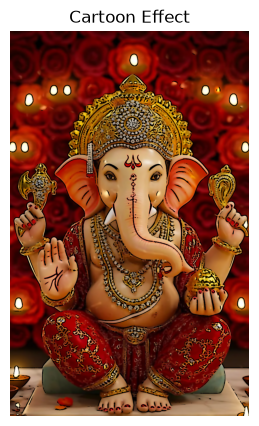

In [11]:
gray_cartoon = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray_blur = cv2.medianBlur(gray_cartoon, 7)

cartoon_edges = cv2.adaptiveThreshold(
    gray_blur,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    9,
    9
)

smooth_color = cv2.bilateralFilter(
    image,
    9,
    250,
    250
)

cartoon = cv2.bitwise_and(
    smooth_color,
    smooth_color,
    mask=cartoon_edges
)

show_image("Cartoon Effect", cartoon)

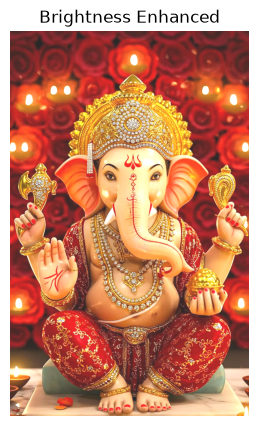

In [12]:
bright_image = cv2.convertScaleAbs(
    image,
    alpha=1.2,
    beta=40
)

show_image("Brightness Enhanced", bright_image)

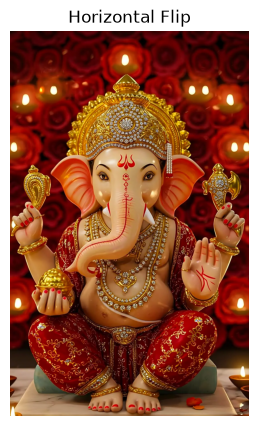

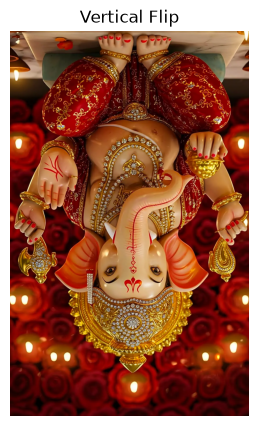

In [13]:
horizontal_flip = cv2.flip(image, 1)
vertical_flip = cv2.flip(image, 0)

show_image("Horizontal Flip", horizontal_flip)
show_image("Vertical Flip", vertical_flip)

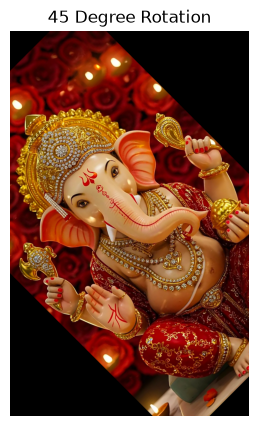

In [14]:
height, width = image.shape[:2]

center = (width // 2, height // 2)

rotation_matrix = cv2.getRotationMatrix2D(
    center,
    45,
    1
)

rotated = cv2.warpAffine(
    image,
    rotation_matrix,
    (width, height)
)

show_image("45 Degree Rotation", rotated)

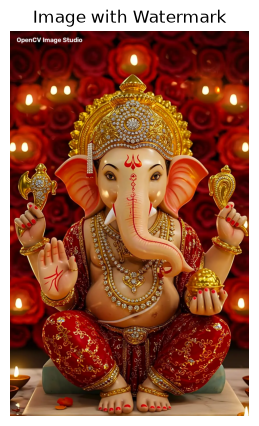

In [15]:
watermarked = image.copy()

cv2.putText(
    watermarked,
    "OpenCV Image Studio",
    (30, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 255, 255),
    2,
    cv2.LINE_AA
)

show_image("Image with Watermark", watermarked)

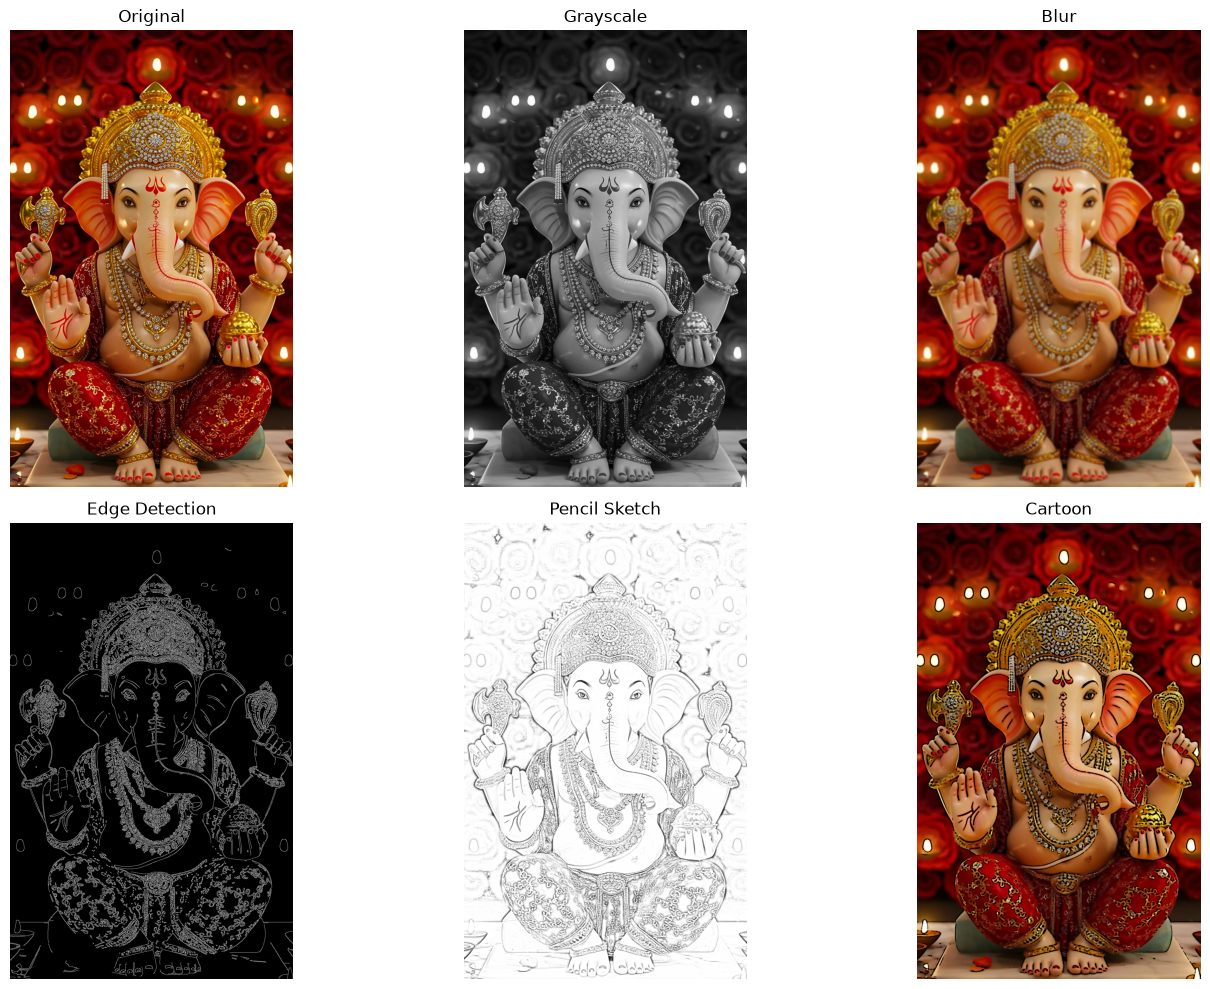

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original")

# Grayscale
axes[0, 1].imshow(gray, cmap="gray")
axes[0, 1].set_title("Grayscale")

# Blur
axes[0, 2].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title("Blur")

# Edge Detection
axes[1, 0].imshow(edges, cmap="gray")
axes[1, 0].set_title("Edge Detection")

# Sketch
axes[1, 1].imshow(sketch, cmap="gray")
axes[1, 1].set_title("Pencil Sketch")

# Cartoon
axes[1, 2].imshow(cv2.cvtColor(cartoon, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("Cartoon")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
def image_studio(choice):

    if choice == 1:
        show_image("Original Image", image)

    elif choice == 2:
        show_image("Grayscale", gray, gray=True)

    elif choice == 3:
        show_image("Blur Effect", blurred)

    elif choice == 4:
        show_image("Edge Detection", edges, gray=True)

    elif choice == 5:
        show_image("Pencil Sketch", sketch, gray=True)

    elif choice == 6:
        show_image("Cartoon Effect", cartoon)

    elif choice == 7:
        show_image("Brightness Enhanced", bright_image)

    elif choice == 8:
        show_image("Horizontal Flip", horizontal_flip)

    elif choice == 9:
        show_image("Vertical Flip", vertical_flip)

    elif choice == 10:
        show_image("Rotated Image", rotated)

    else:
        print("❌ Invalid choice!")


       🎨 OPENCV IMAGE STUDIO

1. Original Image
2. Grayscale
3. Blur
4. Edge Detection
5. Pencil Sketch
6. Cartoon Effect
7. Increase Brightness
8. Horizontal Flip
9. Vertical Flip
10. Rotate Image




Enter your choice (1-10):  10


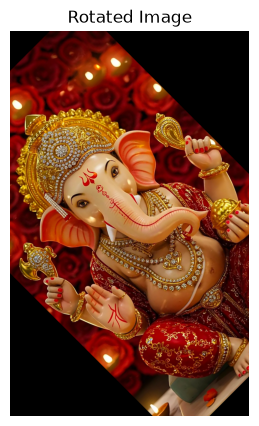

In [18]:
print("""
=================================
       🎨 OPENCV IMAGE STUDIO
=================================

1. Original Image
2. Grayscale
3. Blur
4. Edge Detection
5. Pencil Sketch
6. Cartoon Effect
7. Increase Brightness
8. Horizontal Flip
9. Vertical Flip
10. Rotate Image

=================================
""")

choice = int(input("Enter your choice (1-10): "))

image_studio(choice)

In [19]:
cv2.imwrite("cartoon_output.png", cartoon)

print("✅ Image saved successfully as cartoon_output.png")

✅ Image saved successfully as cartoon_output.png


In [20]:
cv2.imwrite("sketch_output.png", sketch)

True